# 🎓 EduPro – Student Segmentation & Personalized Course Recommendation System
**Unified Mentor project · Learner-centric intelligence for EduPro**

**Objective.** Replace one-size-fits-all recommendations with a data-driven engine that (1) segments learners by behaviour, (2) recommends courses using cluster-aware logic, and (3) supports personalised learning journeys.

**Pipeline:** Load → Learner aggregation → Feature engineering → Preprocessing → K-Means + Hierarchical validation → Segment profiling → Hybrid recommender → Evaluation → Insights & executive summary.

> **Data note.** This notebook reads `data/Users.csv`, `data/Courses.csv`, `data/Transactions.csv`. If Courses/Transactions are missing, `edupro_core.load_data` generates a **clearly-flagged synthetic** substitute (real users, simulated enrolments) so that the whole pipeline can be demonstrated. Drop the real CSVs into `data/` and re-run – nothing else changes.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import edupro_core as ec

sns.set_theme(style="whitegrid", palette="deep"); plt.rcParams["figure.dpi"] = 110

## 2. Load data

In [2]:
data = ec.load_data("data")
users, courses, tx = data["users"], data["courses"], data["tx"]
SYNTH = data["synthetic"]
print("Synthetic sheets:", SYNTH or "none – all real data")
print(f"Users {users.shape} | Courses {courses.shape} | Transactions {tx.shape}")
display(users.head(3)); display(courses.head(3)); display(tx.head(3))

Synthetic sheets: ['Courses', 'Transactions']
Users (3000, 5) | Courses (96, 8) | Transactions (14024, 5)


,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CourseRating,CoursePrice,LevelScore
0,C0001,Python for Data Analysis – Beginner,Data Science,Paid,Beginner,4.3,3990.0,1
1,C0002,Machine Learning – Beginner,Data Science,Free,Beginner,4.0,0.0,1
2,C0003,Statistics – Beginner,Data Science,Paid,Beginner,4.2,4190.0,1


,TransactionID,UserID,CourseID,TransactionDate,Amount
0,T000001,U00001,C0013,2024-05-02,0.0
1,T000002,U00001,C0074,2024-08-17,0.0
2,T000003,U00002,C0013,2023-11-20,0.0


### Data quality checks
Duplicates removed on IDs, invalid dates/amounts coerced, and transactions referencing unknown users/courses dropped inside `load_data` (see `edupro_core.py`).

In [3]:
print("Missing values (users):", users[["Age","Gender"]].isna().sum().to_dict())
print("Users with ≥1 enrolment: %d of %d (%.1f%%)" % (tx.UserID.nunique(), len(users), 100*tx.UserID.nunique()/len(users)))
print("Date range:", tx.TransactionDate.min().date(), "→", tx.TransactionDate.max().date())

Missing values (users): {'Age': 0, 'Gender': 0}
Users with ≥1 enrolment: 2889 of 3000 (96.3%)
Date range: 2023-01-03 → 2026-01-26


## 3. Exploratory data analysis

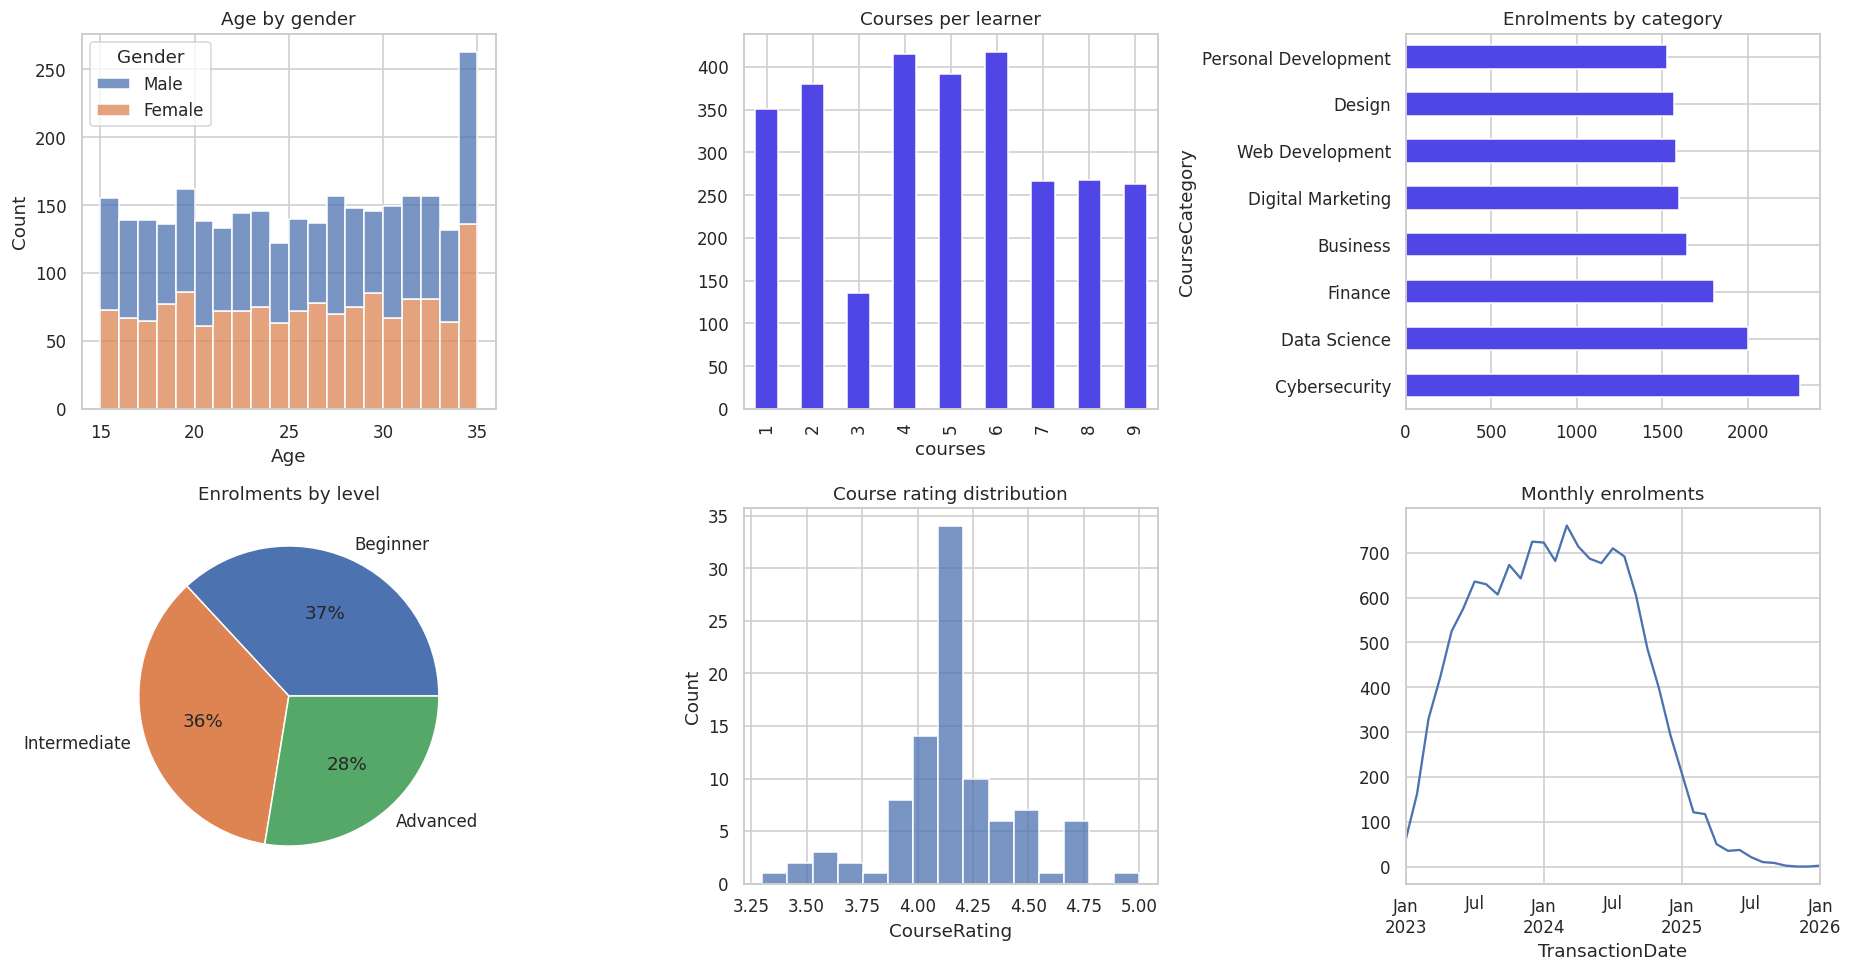

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
sns.histplot(data=users, x="Age", hue="Gender", multiple="stack", bins=20, ax=ax[0,0]); ax[0,0].set_title("Age by gender")
tx.groupby("UserID").size().value_counts().sort_index().plot.bar(ax=ax[0,1], color="#4F46E5"); ax[0,1].set_title("Courses per learner"); ax[0,1].set_xlabel("courses")
t = tx.merge(courses, on="CourseID")
t.CourseCategory.value_counts().plot.barh(ax=ax[0,2], color="#4F46E5"); ax[0,2].set_title("Enrolments by category")
t.CourseLevel.value_counts().reindex(ec.LEVELS).plot.pie(ax=ax[1,0], autopct="%1.0f%%"); ax[1,0].set_ylabel(""); ax[1,0].set_title("Enrolments by level")
sns.histplot(courses.CourseRating, bins=15, ax=ax[1,1]); ax[1,1].set_title("Course rating distribution")
t.set_index("TransactionDate").resample("ME").size().plot(ax=ax[1,2]); ax[1,2].set_title("Monthly enrolments")
plt.tight_layout(); plt.show()

## 4. Learner-level aggregation & feature engineering
Each learner becomes one row combining demographics with behaviour.

| Group | Features |
|---|---|
| Engagement | `total_courses`, `avg_courses_per_category`, `enroll_frequency` (courses / active month) |
| Preference | `preferred_category`, `preferred_level`, `avg_rating` of enrolled courses |
| Behavioural | `avg_spend`, `n_categories` (**diversity score**), `learning_depth_index` = (advanced+1)/(beginner+1) |
| Extra | `paid_share`, `Age`, `Gender` |

In [5]:
feat = ec.build_features(users, courses, tx)
display(feat[ec.NUM_FEATURES + ["preferred_category","preferred_level"]].describe(include="all").T.round(2))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_courses,3000.0,NaN,NaN,NaN,4.674667,2.617972,0.0,2.0,5.0,7.0,9.0
avg_courses_per_category,3000.0,NaN,NaN,NaN,1.434472,0.718264,0.0,1.0,1.25,1.666667,7.0
enroll_frequency,3000.0,NaN,NaN,NaN,1.383869,0.813089,0.0,0.907463,1.160305,1.805941,5.883871
avg_spend,3000.0,NaN,NaN,NaN,1446.663531,883.270428,0.0,892.812024,1501.6025,2024.558333,4347.61
avg_rating,3000.0,NaN,NaN,NaN,4.211675,0.173391,3.5,4.12,4.2,4.3,5.0
n_categories,3000.0,NaN,NaN,NaN,3.273333,1.863629,0.0,2.0,3.0,4.0,8.0
learning_depth_index,3000.0,NaN,NaN,NaN,1.418939,1.436367,0.1,0.333333,1.0,2.0,8.0
paid_share,3000.0,NaN,NaN,NaN,0.629746,0.334829,0.0,0.5,0.666667,1.0,1.0
Age,3000.0,NaN,NaN,NaN,24.974333,6.046475,15.0,20.0,25.0,30.0,35.0
preferred_category,3000,9,Cybersecurity,532,NaN,NaN,NaN,NaN,NaN,NaN,NaN


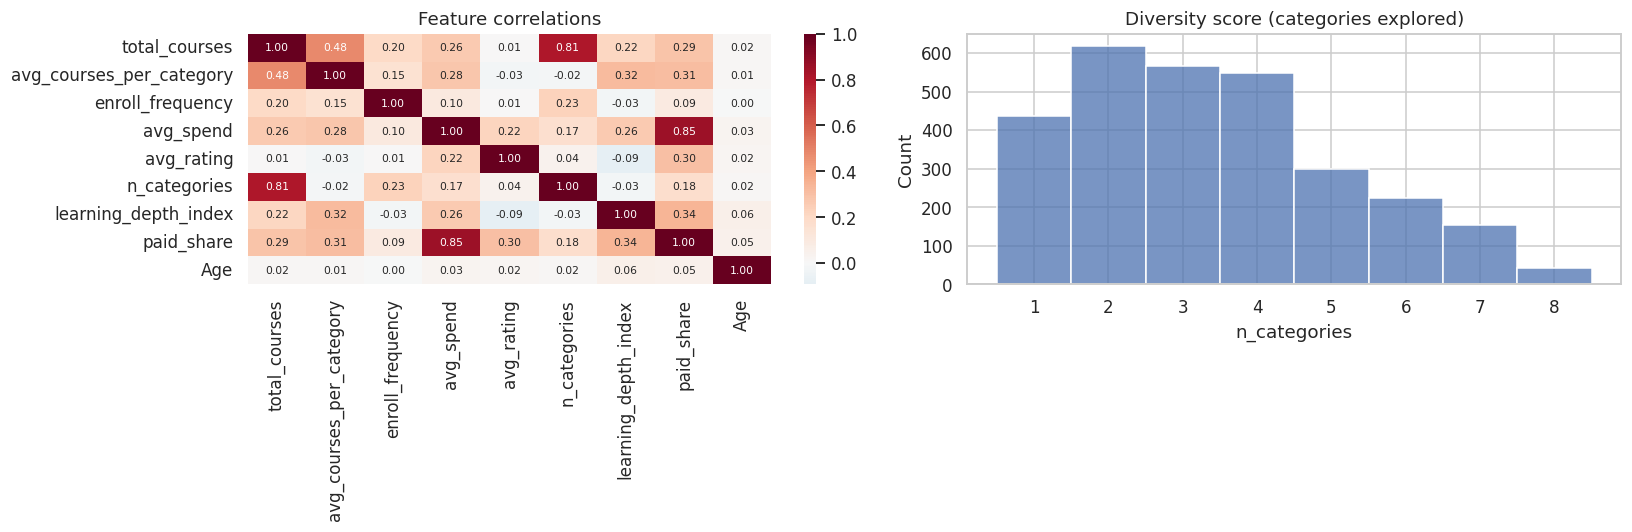

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(feat[ec.NUM_FEATURES].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[0], annot_kws={"size": 7})
ax[0].set_title("Feature correlations")
sns.histplot(feat.query("total_courses>0").n_categories, discrete=True, ax=ax[1]); ax[1].set_title("Diversity score (categories explored)")
plt.tight_layout(); plt.show()

## 5. Preprocessing
* **Log-transform** right-skewed counts/spend/ratios, then **standardise** (z-score).
* **Clip** z-scores at ±3.5 so outliers don't dominate distances.
* **One-hot encode** gender, preferred level, preferred category (down-weighted so demographics don't overpower behaviour).
* **Sparse learners** (< 2 enrolments) are *excluded when fitting* clusters to reduce noise, but still get a segment via their nearest centroid.

In [7]:
MIN_ENROLL = 2
X, active = ec.prepare(feat, MIN_ENROLL)
print(f"Feature matrix: {X.shape} | fitting on {active.sum():,} active learners; {(~active).sum():,} sparse learners assigned afterwards")

Feature matrix: (3000, 24) | fitting on 2,538 active learners; 462 sparse learners assigned afterwards


## 6. Choosing k – Elbow & Silhouette

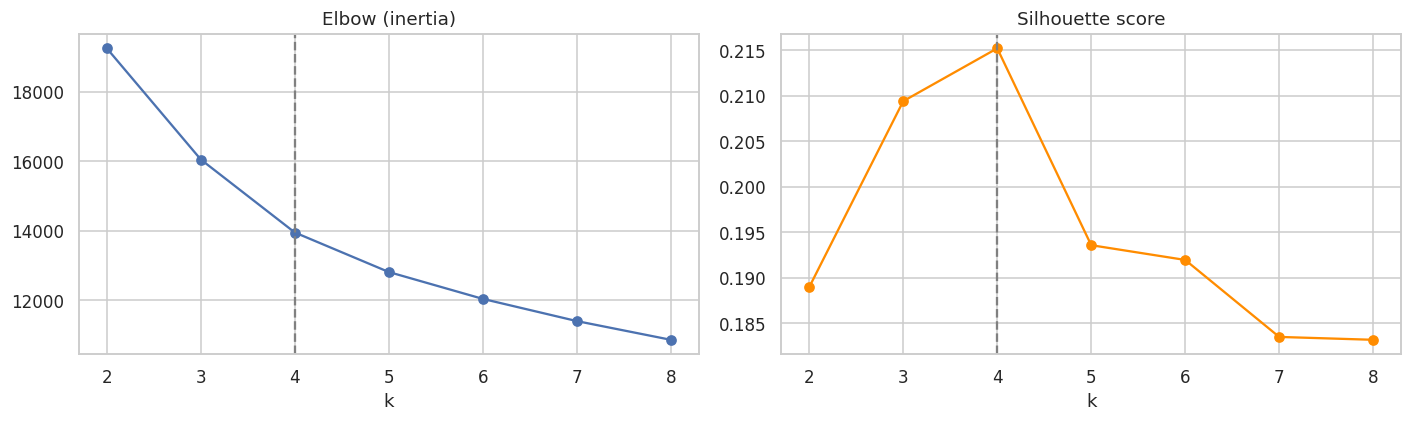

,k,inertia,silhouette
0,2,19256.881,0.189
1,3,16055.664,0.209
2,4,13954.226,0.215
3,5,12816.277,0.194
4,6,12043.008,0.192
5,7,11403.775,0.184
6,8,10864.893,0.183


Selected k = 4 (highest silhouette with k ≥ 3, so segments stay actionable)


In [8]:
sweep = ec.sweep_k(X[active], range(2, 9))
best_k = ec.choose_k(sweep)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sweep.k, sweep.inertia, "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(sweep.k, sweep.silhouette, "o-", color="darkorange"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
for a in ax: a.axvline(best_k, ls="--", c="grey")
plt.tight_layout(); plt.show()
display(sweep.round(3)); print("Selected k =", best_k, "(highest silhouette with k ≥ 3, so segments stay actionable)")

## 7. K-Means segmentation

Silhouette (K-Means, k=4): 0.215


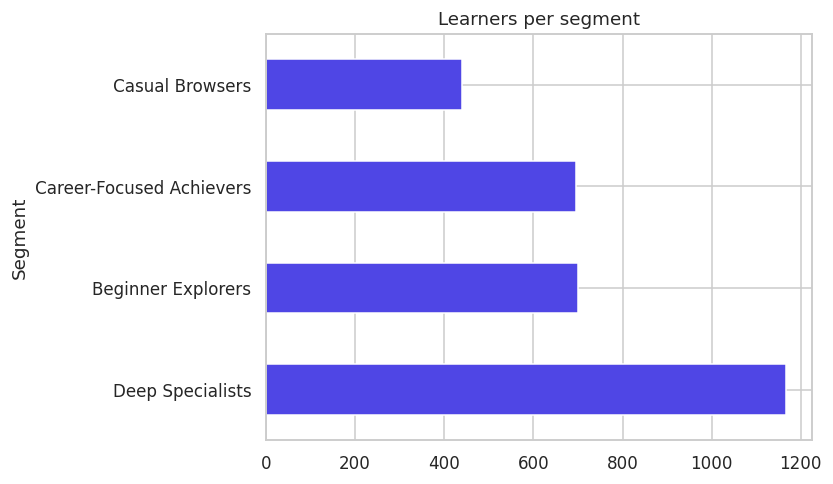

In [9]:
km, labels = ec.fit_kmeans(X, active, best_k)
names = ec.name_segments(feat, labels)
feat["Cluster"] = labels; feat["Segment"] = feat.Cluster.map(names); feat["low_activity"] = ~active
sil = ec.silhouette_score(X[active], labels[active], sample_size=3000, random_state=42)
print(f"Silhouette (K-Means, k={best_k}): {sil:.3f}")
feat.Segment.value_counts().plot.barh(color="#4F46E5"); plt.title("Learners per segment"); plt.show()

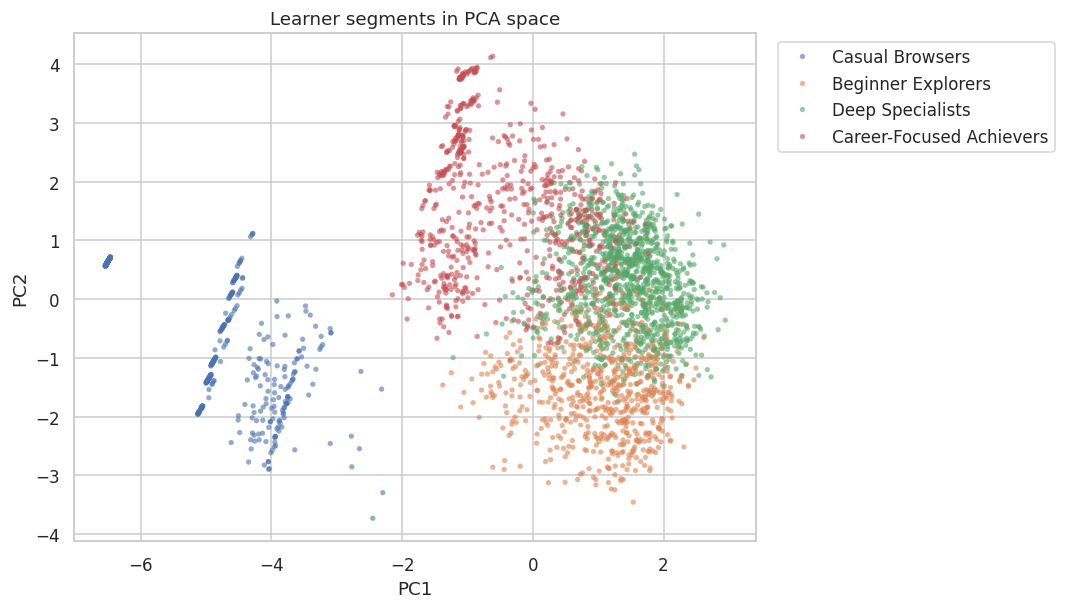

In [10]:
from sklearn.decomposition import PCA
pc = PCA(2, random_state=42).fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=feat.Segment, s=12, alpha=.6, linewidth=0)
plt.title("Learner segments in PCA space"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(bbox_to_anchor=(1.02,1)); plt.show()

## 8. Hierarchical clustering – validation of K-Means

hier_silhouette                     0.170
kmeans_silhouette_same_sample       0.213
adjusted_rand_index                 0.597
sample_size                      1500.000


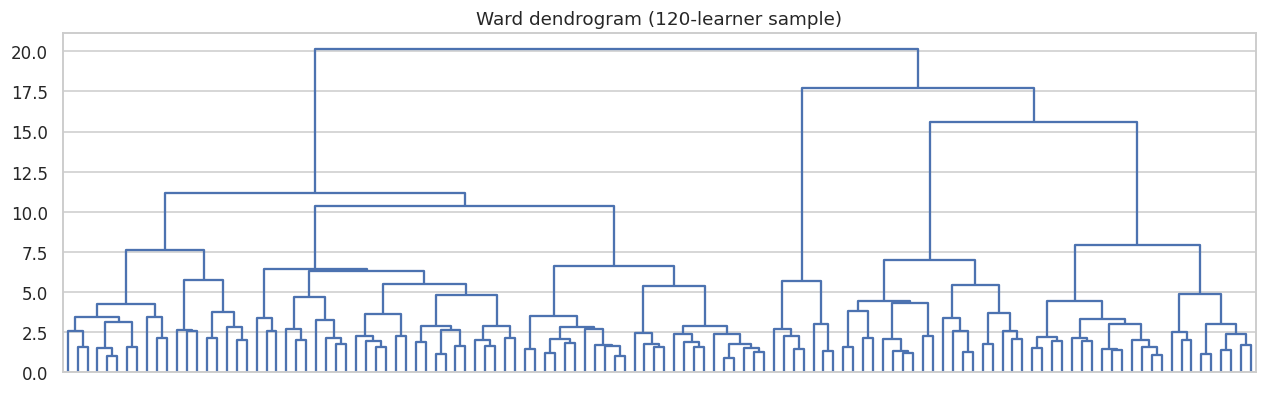

In [11]:
h = ec.hierarchical_validation(X[active], labels[active], best_k)
print(pd.Series(h).round(3).to_string())
rng = np.random.default_rng(0); idx = rng.choice(active.sum(), 120, replace=False)
plt.figure(figsize=(14, 4)); dendrogram(linkage(X[active][idx], "ward"), no_labels=True, color_threshold=0)
plt.title("Ward dendrogram (120-learner sample)"); plt.show()

An **Adjusted Rand Index** well above 0 shows the independently-built hierarchical partition recovers much of the K-Means structure, i.e. the segments are not an artefact of one algorithm.

## 9. Segment profiling

Segment,Beginner Explorers,Career-Focused Achievers,Casual Browsers,Deep Specialists
Learners,700.00,695.00,439.00,1166.00
total_courses,6.82,2.48,1.12,6.04
avg_courses_per_category,1.20,1.14,0.79,2.00
enroll_frequency,1.70,1.40,0.89,1.38
avg_spend,1295.11,1906.39,0.00,1808.30
avg_rating,4.21,4.31,4.11,4.19
n_categories,5.71,2.19,1.07,3.28
learning_depth_index,0.33,0.85,0.69,2.69
paid_share,0.55,0.82,0.00,0.80
Age,25.01,24.71,24.32,25.35


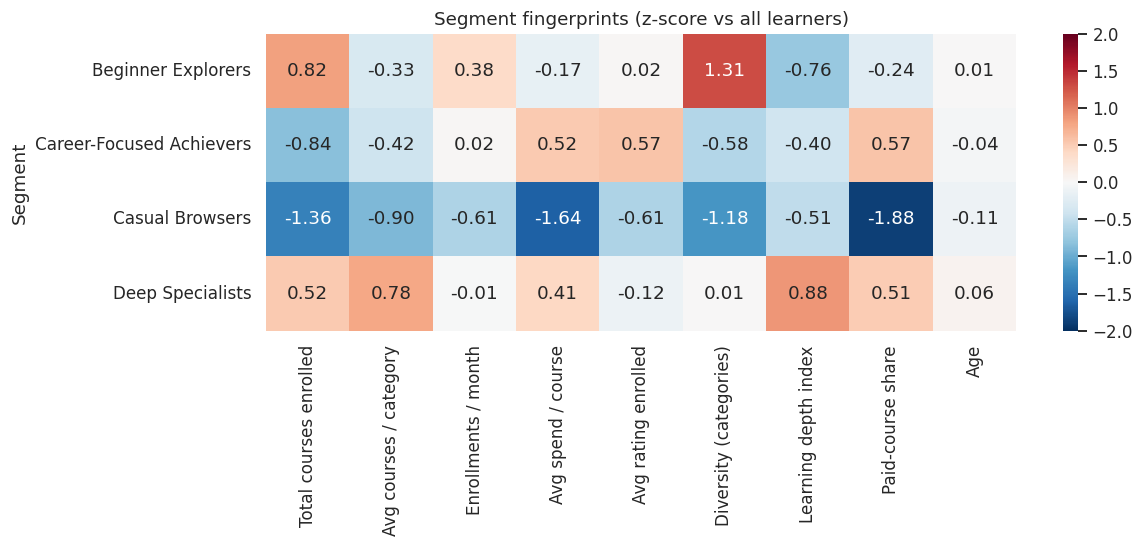

In [12]:
prof = ec.segment_profile(feat)
display(prof.round(2).T)
z = (prof[ec.NUM_FEATURES] - feat[ec.NUM_FEATURES].mean()) / feat[ec.NUM_FEATURES].std()
z.columns = [ec.FEATURE_LABELS[c] for c in z.columns]
plt.figure(figsize=(11, 3.5)); sns.heatmap(z, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-2, vmax=2)
plt.title("Segment fingerprints (z-score vs all learners)"); plt.show()

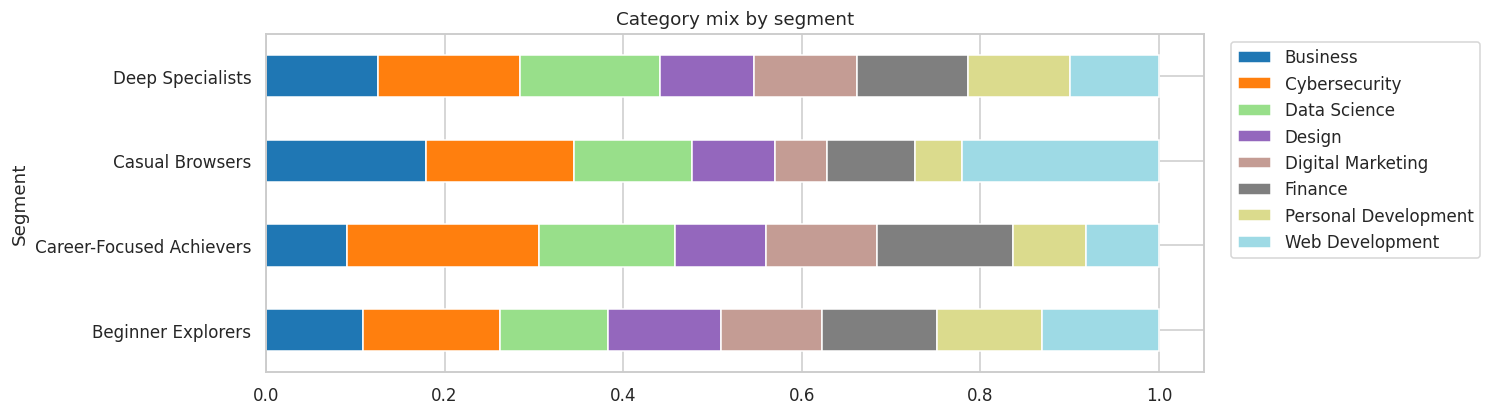

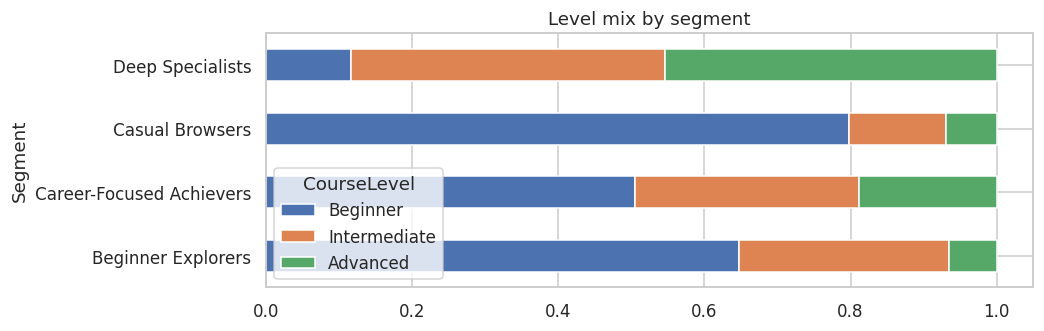

In [13]:
t = tx.merge(courses, on="CourseID").merge(feat[["Segment"]], left_on="UserID", right_index=True)
mix = pd.crosstab(t.Segment, t.CourseCategory, normalize="index")
mix.plot.barh(stacked=True, figsize=(11, 4), colormap="tab20"); plt.title("Category mix by segment"); plt.legend(bbox_to_anchor=(1.02,1)); plt.show()
pd.crosstab(t.Segment, t.CourseLevel, normalize="index")[ec.LEVELS].plot.barh(stacked=True, figsize=(9, 3)); plt.title("Level mix by segment"); plt.show()

## 10. Personalised recommendation engine
**Hybrid, cluster-aware scoring** for learner *u* and candidate course *c*:

`relevance = 0.40·Content + 0.30·ClusterPopularity + 0.30·SimilarLearners`  →  `score = relevance × (0.75 + 0.25·normalised_rating)`

* **Content-based** – affinity to the learner's category history + closeness to their (slightly progressed) level.
* **Cluster popularity** – share of the learner's segment that took the course.
* **Similar learners** – kNN (k=30) within the segment in feature space; course score = similarity-weighted uptake.
* **Rating-weighted** – higher-rated courses get a gentle boost. Already-taken courses are excluded; cold-start learners fall back on segment popularity + beginner content.

In [14]:
rec = ec.Recommender(courses, tx, feat, X, labels, names)
demo = feat[feat.total_courses >= 4].groupby("Segment").head(1).index[:4]
for u in demo:
    print(f"\n=== {u} | {feat.loc[u,'Segment']} | top category: {feat.loc[u,'preferred_category']} | level: {feat.loc[u,'preferred_level']}")
    display(rec.recommend(u, n=5)[["Course","Category","Level","Rating","Score","Why"]])


=== U00003 | Beginner Explorers | top category: Web Development | level: Beginner


,Course,Category,Level,Rating,Score,Why
0,Risk & Compliance – Beginner,Cybersecurity,Beginner,4.7,0.7229,Popular among Beginner Explorers
1,Machine Learning – Beginner,Data Science,Beginner,4.0,0.6984,Matches your interest in Data Science
2,React – Beginner,Web Development,Beginner,4.5,0.6109,Matches your interest in Web Development (your...
3,Cloud Security – Beginner,Cybersecurity,Beginner,4.5,0.5658,Matches your interest in Cybersecurity
4,Backend with Node – Beginner,Web Development,Beginner,4.2,0.5616,Matches your interest in Web Development (your...



=== U00004 | Deep Specialists | top category: Business | level: Intermediate


,Course,Category,Level,Rating,Score,Why
0,Entrepreneurship – Advanced,Business,Advanced,4.0,0.6429,Matches your interest in Business (your top ca...
1,Project Management – Advanced,Business,Advanced,4.2,0.6289,Matches your interest in Business (your top ca...
2,Management Essentials – Advanced,Business,Advanced,4.1,0.5447,Matches your interest in Business (your top ca...
3,Content Marketing – Intermediate,Digital Marketing,Intermediate,4.7,0.5036,Matches your interest in Digital Marketing
4,Ethical Hacking – Intermediate,Cybersecurity,Intermediate,4.7,0.4907,Popular among Deep Specialists



=== U00054 | Career-Focused Achievers | top category: Digital Marketing | level: Intermediate


,Course,Category,Level,Rating,Score,Why
0,Risk & Compliance – Beginner,Cybersecurity,Beginner,4.7,0.7394,Popular among Career-Focused Achievers
1,Ethical Hacking – Intermediate,Cybersecurity,Intermediate,4.7,0.6837,Matches your interest in Cybersecurity
2,Analytics – Beginner,Digital Marketing,Beginner,4.5,0.4548,Matches your interest in Digital Marketing (yo...
3,Analytics – Intermediate,Digital Marketing,Intermediate,4.2,0.3773,Matches your interest in Digital Marketing (yo...
4,SEO – Advanced,Digital Marketing,Advanced,4.4,0.3762,Matches your interest in Digital Marketing (yo...



=== U00129 | Casual Browsers | top category: Finance | level: Beginner


,Course,Category,Level,Rating,Score,Why
0,Ethical Hacking – Beginner,Cybersecurity,Beginner,4.4,0.6044,Taken by learners with a similar profile
1,Backend with Node – Beginner,Web Development,Beginner,4.2,0.5228,Matches your interest in Web Development
2,React – Beginner,Web Development,Beginner,4.5,0.5015,Matches your interest in Web Development
3,JavaScript – Beginner,Web Development,Beginner,3.9,0.4872,Matches your interest in Web Development
4,Network Security – Beginner,Cybersecurity,Beginner,4.5,0.4603,Taken by learners with a similar profile


### Learning path & filters

In [15]:
u = demo[0]
print("Learning path for", u); display(ec.learning_path(rec.recommend(u, n=10))[["Step","Course","Level","Rating"]])
print("Filtered: Advanced only"); display(rec.recommend(u, n=5, levels=["Advanced"])[["Course","Category","Level","Rating"]])

Learning path for U00003


,Step,Course,Level,Rating
0,1,Risk & Compliance – Beginner,Beginner,4.7
1,2,Machine Learning – Beginner,Beginner,4.0
2,3,React – Beginner,Beginner,4.5
3,4,Cloud Security – Beginner,Beginner,4.5
4,5,Backend with Node – Beginner,Beginner,4.2


Filtered: Advanced only


,Course,Category,Level,Rating
0,Statistics – Advanced,Data Science,Advanced,4.2
1,HTML & CSS – Advanced,Web Development,Advanced,4.4
2,Data Visualization – Advanced,Data Science,Advanced,4.3
3,Python for Data Analysis – Advanced,Data Science,Advanced,4.3
4,React – Advanced,Web Development,Advanced,4.0


## 11. Evaluation & validation
| Metric | Purpose | How measured |
|---|---|---|
| Silhouette | Cluster quality | K-Means & Ward |
| Intra-cluster similarity | Behavioural consistency | mean pairwise cosine within segment vs. all learners |
| Recommendation precision | Relevance | leave-last-out: hide each learner's latest enrolment, refit, check top-K |
| Engagement lift (proxy) | Impact estimate | relative hit-rate gain over global-popularity baseline |

In [16]:
intra, overall = ec.intra_cluster_similarity(X[active], labels[active])
sim = intra.rename(index=names).to_frame("Intra-cluster similarity"); sim.loc["All learners (baseline)"] = overall
display(sim.round(3))

,Intra-cluster similarity
Beginner Explorers,0.468
Deep Specialists,0.264
Career-Focused Achievers,0.331
Casual Browsers,0.831
All learners (baseline),0.036


Evaluated on 1500 learners


,Model,HitRate@5,Precision@5,HitRate@10,Precision@10,EngagementLift@5 (%),EngagementLift@10 (%)
0,Random,0.0550,0.0110,0.1099,0.0110,-57.7211,-51.6458
1,Global popularity,0.1300,0.0260,0.2273,0.0227,0.0000,0.0000
2,Cluster popularity,0.1593,0.0319,0.2593,0.0259,22.5641,14.0762
3,Hybrid (cluster-aware),0.1980,0.0396,0.3167,0.0317,52.3077,39.2962


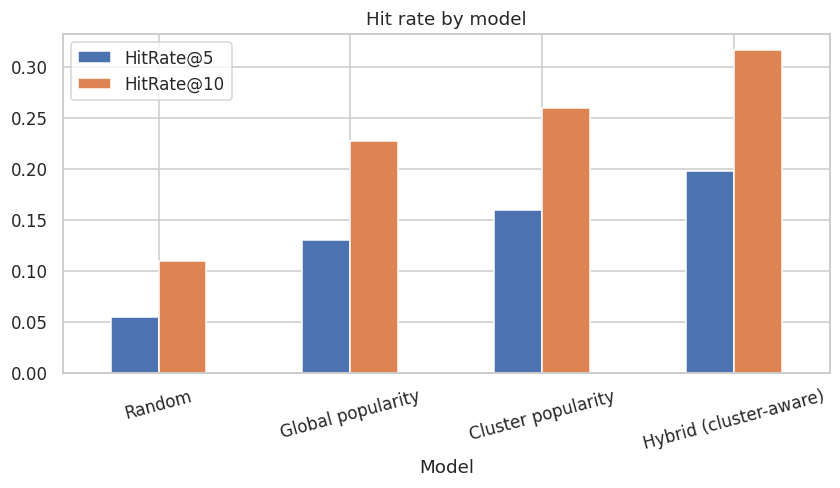

In [17]:
res = ec.evaluate(users, courses, tx, best_k, min_enroll=MIN_ENROLL, max_users=1500)
print("Evaluated on", res.attrs["n_eval_users"], "learners")
display(res.round(4))
res.set_index("Model")[["HitRate@5","HitRate@10"]].plot.bar(rot=15, figsize=(9,4)); plt.title("Hit rate by model"); plt.show()

## 12. Insights, recommendations & executive summary

In [18]:
sizes = feat.Segment.value_counts(normalize=True).mul(100).round(1)
hyb = res[res.Model == "Hybrid (cluster-aware)"].iloc[0]
lift5, lift10 = hyb["EngagementLift@5 (%)"], hyb["EngagementLift@10 (%)"]
tag = "ILLUSTRATIVE (synthetic " + " & ".join(SYNTH) + " data)" if SYNTH else "based on EduPro production data"
lines = [f"EXECUTIVE SUMMARY – {tag}", "=" * 70,
 f"• {len(feat):,} learners were grouped into {best_k} behavioural segments (silhouette {sil:.2f}; Ward cross-check ARI {h['adjusted_rand_index']:.2f}).",
 "• Segment shares: " + "; ".join(f"{k} {v}%" for k, v in sizes.items()) + ".",
 f"• The hybrid recommender placed the hidden next course in the top-10 for {hyb['HitRate@10']:.0%} of learners, a {lift10:+.0f}% lift over global popularity (top-5: {lift5:+.0f}%).",
 "", "RECOMMENDED ACTIONS"]
actions = {
 "Beginner Explorers": "Guided 'first pathway' bundles and free-to-paid nudges; convert breadth into a chosen specialism.",
 "Deep Specialists": "Advanced tracks, capstones and cohort communities; surface next-level courses in their category.",
 "Career-Focused Achievers": "Certification-style bundles, rating/credential badges and career-outcome messaging.",
 "Casual Browsers": "Onboarding drip, low-friction starter courses, re-engagement campaigns after 30 days of inactivity.",
 "Engaged Power Learners": "Loyalty perks, early access, peer-mentor roles.",
}
for s in sizes.index: lines.append(f"• {s}: " + actions.get(s, "Tailor messaging to this segment's fingerprint (see heatmap)."))
lines += ["", "NEXT STEPS: pilot segment-aware recommendations with an A/B test to convert the offline lift proxy into measured completion/retention impact; refresh segments monthly."]
print("\n".join(lines))

EXECUTIVE SUMMARY – ILLUSTRATIVE (synthetic Courses & Transactions data)
• 3,000 learners were grouped into 4 behavioural segments (silhouette 0.22; Ward cross-check ARI 0.60).
• Segment shares: Deep Specialists 38.9%; Beginner Explorers 23.3%; Career-Focused Achievers 23.2%; Casual Browsers 14.6%.
• The hybrid recommender placed the hidden next course in the top-10 for 32% of learners, a +39% lift over global popularity (top-5: +52%).

RECOMMENDED ACTIONS
• Deep Specialists: Advanced tracks, capstones and cohort communities; surface next-level courses in their category.
• Beginner Explorers: Guided 'first pathway' bundles and free-to-paid nudges; convert breadth into a chosen specialism.
• Career-Focused Achievers: Certification-style bundles, rating/credential badges and career-outcome messaging.
• Casual Browsers: Onboarding drip, low-friction starter courses, re-engagement campaigns after 30 days of inactivity.

NEXT STEPS: pilot segment-aware recommendations with an A/B test to co

### Limitations & ethics
* Offline metrics are proxies – true engagement/completion lift requires an online experiment.
* Gender and age are low-weight inputs; review segments for unintended demographic skew before targeting.
* Sparse learners (< 2 enrolments) get lower-confidence segments.
* If synthetic substitutes were used (see the banner at the top), numbers are illustrative only.

### Deployment
`streamlit run app.py` – see `README.md` for Streamlit Community Cloud steps.